In [31]:
import pandas as pd
import numpy as np

In [32]:
df = pd.DataFrame()

In [33]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [34]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


In [35]:
df['weights']=1/df.shape[0]
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [36]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

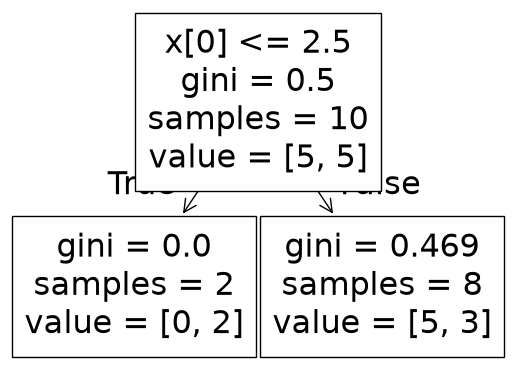

In [37]:
# This is decision stump
from sklearn.tree import DecisionTreeClassifier,plot_tree
dtc=DecisionTreeClassifier(max_depth=1)
dtc.fit(X,y)
plot_tree(dtc)

In [38]:
df['y_pred']=dtc.predict(X)

In [39]:
def calcError(err):
  return 0.5*(np.log(1+err/err))

alpha1=calcError(0.3)
alpha1

np.float64(0.34657359027997264)

In [40]:
def calcWeight(df,alpha1=0.346):
  if df['label'] == df['y_pred']:
    return df['weights'] * np.exp(-calcError(0.3))
  else:
    return df['weights']*np.exp(calcError(0.3))

df['updated_weights']=df.apply(calcWeight,axis=1)

In [41]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.070711
1,2,3,1,0.1,1,0.070711
2,3,6,0,0.1,0,0.070711
3,4,8,1,0.1,0,0.141421
4,5,1,0,0.1,0,0.070711
5,6,9,1,0.1,0,0.141421
6,6,5,0,0.1,0,0.070711
7,7,8,1,0.1,0,0.141421
8,9,9,0,0.1,0,0.070711
9,9,2,0,0.1,0,0.070711


In [42]:
df['normalized_weights']=df['updated_weights']/df['updated_weights'].sum()

In [43]:
df['normalized_weights'].sum()

np.float64(0.9999999999999998)

In [44]:
df['upper_limit']=np.cumsum(df['normalized_weights'])
df['lower_limit']=df['upper_limit']-df['normalized_weights']

In [45]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,upper_limit,lower_limit
0,1,5,1,0.1,1,0.070711,0.076923,0.076923,0.000000
1,2,3,1,0.1,1,0.070711,0.076923,0.153846,0.076923
2,3,6,0,0.1,0,0.070711,0.076923,0.230769,0.153846
3,4,8,1,0.1,0,0.141421,0.153846,0.384615,0.230769
4,5,1,0,0.1,0,0.070711,0.076923,0.461538,0.384615
5,6,9,1,0.1,0,0.141421,0.153846,0.615385,0.461538
6,6,5,0,0.1,0,0.070711,0.076923,0.692308,0.615385
7,7,8,1,0.1,0,0.141421,0.153846,0.846154,0.692308
8,9,9,0,0.1,0,0.070711,0.076923,0.923077,0.846154
9,9,2,0,0.1,0,0.070711,0.076923,1.000000,0.923077


In [46]:
def new_dataset(df):
  indexes=[]
  for i in range(df.shape[0]):
     num=np.random.random()
     for idx,rows in df.iterrows():
      if rows['upper_limit']>num and rows['lower_limit']<num:
        indexes.append(idx)
  return indexes

idx=new_dataset(df)
idx

[4, 6, 0, 5, 4, 8, 2, 7, 3, 8]

In [47]:
second_df=df.iloc[idx,0:4]
df.iloc[:,2]

0    1
1    1
2    0
3    1
4    0
5    1
6    0
7    1
8    0
9    0
Name: label, dtype: int64

In [48]:
dt2=DecisionTreeClassifier(max_depth=1)
dt2.fit(second_df.iloc[:,:2],second_df.iloc[:,2])
second_df['y_pred']=dt2.predict(second_df.iloc[:,:2])

In [49]:
second_df

,X1,X2,label,weights,y_pred
4,5,1,0,0.1,0
6,6,5,0,0.1,0
0,1,5,1,0.1,0
5,6,9,1,0.1,1
4,5,1,0,0.1,0
8,9,9,0,0.1,1
2,3,6,0,0.1,0
7,7,8,1,0.1,1
3,4,8,1,0.1,1
8,9,9,0,0.1,1


In [50]:
def calcError(err):
  return 0.5*(np.log(1+err/err+0.00000001))
alpha1=calcError(0.3)

second_df['updated_weights']=df.apply(calcWeight,axis=1)
alpha1

np.float64(0.34657359277997263)

In [51]:
second_df['normalized_weights']=second_df['updated_weights']/second_df['updated_weights'].sum()
second_df['upper_limit']=np.cumsum(second_df['normalized_weights'])
second_df['lower_limit']=second_df['upper_limit']-second_df['normalized_weights']

In [52]:
new_dataset(second_df)

[5, 7, 4, 7, 8, 7, 4, 2, 3, 4]

In [53]:
third_df=second_df.iloc[idx,0:4]

In [54]:
dt3=DecisionTreeClassifier(max_depth=1)
dt3.fit(third_df.iloc[:,:2],third_df.iloc[:,2])
third_df['y_pred']=dt3.predict(third_df.iloc[:,:2])

In [55]:
def calcError(err):
  return 0.5*(np.log(1+err/err+0.00000001))

alpha1=calcError(0.3)
alpha1
third_df['updated_weights']=df.apply(calcWeight,axis=1)

In [56]:
third_df['normalized_weights']=third_df['updated_weights']/third_df['updated_weights'].sum()
third_df['upper_limit']=np.cumsum(third_df['normalized_weights'])
third_df['lower_limit']=third_df['upper_limit']-third_df['normalized_weights']

In [57]:
new_dataset(third_df)

[7, 4, 5, 3, 5, 3, 3, 4, 5, 7]

In [58]:
fourth_df=third_df.iloc[idx,0:4]

In [59]:
dt4=DecisionTreeClassifier(max_depth=1)
dt4.fit(fourth_df.iloc[:,:2],fourth_df.iloc[:,2])
fourth_df['y_pred']=dt4.predict(fourth_df.iloc[:,:2])

In [60]:
fourth_df

,X1,X2,label,weights,y_pred
4,5,1,0,0.1,0
0,1,5,1,0.1,1
4,5,1,0,0.1,0
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
4,5,1,0,0.1,0
7,7,8,1,0.1,1
8,9,9,0,0.1,1
5,6,9,1,0.1,1
